In [27]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri("../mlruns")
experiment_id = "914879025403898454"

In [28]:
# alpha_runs = ["c8ad1c65110343a39cadedcee3976006","f6b0e706b2fc40d1b0ba52e10c586eac","11b6b289744743238aa3e061c56934af","aeacdcb63dc64629b6fcdda0deb59f9f","1a7b638211734466b88cd99261752acd","d17296ebd3ef41b8a015bf9c823dfca1","3a4f176c8367458cb9530dc0bfb0e89e","5e4999df35784c2ca79263a05f833bbe","470a3c23e5464aaca3920f77a155a449","85bedc656d3d4ff9a565212fa0e6ee90","6f4d2ce868154e38a7e00446473547b3","d29a471203d44b16a4676d16f310d65f","bc11e6b30b7c4f7095fd582f44914a75","62c16367a3cb4f9e9fda6153bff96a8e","39fd421ae9614c9e8f402efab6eb5f76","ad6dbe09dc3c48e982b55464a7015fab","6b1854863aea4c0e8d8610656e7c3a95","fd6d6d3c92cb46088d1c65e9ca2aee0c","37b545c3d17146fc8ea4aa2643ff537b","8178affb63f9481baba894575a4056ae"]
alpha_runs = runs = ["33ab3c853c224738a525f7da4aa5a7b1","788136a55df441458b294b7669666c35","4adb5f93144943d0a1d03e5124830674","4481a312153646869bf01813b5f34cfa","497e542aa6354f2082965a7ec5b2022c","89da1aef3f3c4d48afa87ee7c14d148b","2e5ff47bfd584a5eb39d54e9549b143b","a337d93ebe7f413ebc8b03a3b5beaa9c","c72518ad77d847f884302d6c5107ffb4","600806ce142147938d2b928d9eb1f558","1539f99d0c674bad9183852b958f32da","4f745599821546f8926f124bf92dfa3f","4b6cd21eb1374fd7aaed9c049e591153","1ec823fd69e84a29896def6137f73c68","28a2f29b13c2499fbbd26dc5e153db5d","f6bcdbb3907a41f09d2edd41c22c9e7e","4a2fae2a7b6f41c286ac67110b90495b","799b1ae1916d4ec089e411318a8a08a6","703ed7b242ba427893f09a4c86ea10da","c15a524a61ef491284fe3d16e56c17c2"]

In [29]:
smaller_alpha = ["bb0b5227207c4606b491bef6ff3e4d26", "b0edd6b80e5e442bb38607b1e3ef70f3","1ac8cc123efb45959ec30b3f65eaaaab","ffe165464f244e9b8a3c6bd1b11c5ce2","a5abc2d511604bf297b18912b4f4fec0","013b1a8b968844a9b96881cef7f540ab","2a3bfd35925840cf9aa4eaf896fd491a","e0a64850a99f404bbc2522671a0437f3","fec0f44451994614b4752a37227bdd74","1faa266be97143848cc5ba5710b337de","b25f0fe3ec374dedbfd1662a50c8d6aa","e9f936daa00245f684cd8a9e06727a9d","b7880258cb6143aba134adec2c9cb8ab"]

In [30]:
client = mlflow.tracking.MlflowClient()
ids_str = ", ".join(f"'{run}'" for run in alpha_runs+smaller_alpha)  # Оборачиваем каждое значение в одинарные кавычки
filter_string = f"attributes.run_id IN ({ids_str})"  # Формируем финальный запрос
runs = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_alpha_vs_aee(runs_data, metric='mean_aee_target_attack_step_'):
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Determine the keyword in the metric name for title adjustment
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name

    # Copy and preprocess data
    runs_data = runs_data.copy()
    runs_data["params.alpha"] = runs_data["params.alpha"].astype(float)
    runs_data["params.no_softmax"] = runs_data["params.no_softmax"].astype(str)

    # Group by attack type
    alpha_groups = runs_data.groupby("params.attack_type")

    # Assign colors based on unique alpha values
    unique_alphas = sorted(runs_data["params.alpha"].unique())
    colors = plt.cm.viridis(np.linspace(
        0, 1, len(unique_alphas)))  # Gradient color map
    alpha_color_map = {alpha: colors[idx]
                       for idx, alpha in enumerate(unique_alphas)}

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15 for different alpha (ε=8/255)', fontsize=16)

    for idx, (attack_type, group) in enumerate(alpha_groups):
        ax = axes[idx]
        ax.set_title(
            f'Attack: {attack_type} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        for alpha in unique_alphas:
            attack_rows = group[group["params.alpha"] == alpha]
            if attack_rows.empty:
                continue

            values = {}
            for _, row in attack_rows.iterrows():
                for column, value in row.items():
                    if column.startswith('metrics.' + metric):
                        step_number = re.search(r'(\d+)$', column)
                        if step_number:
                            step_number = int(step_number.group(1))
                            values[step_number] = value

            sorted_items = sorted(values.items())
            sorted_steps = [key for key, value in sorted_items]
            sorted_metrics = [value for key, value in sorted_items]

            legend_label = f"Alpha: {alpha}"
            ax.plot(sorted_steps, sorted_metrics, marker="o",
                    label=legend_label, color=alpha_color_map[alpha])

        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

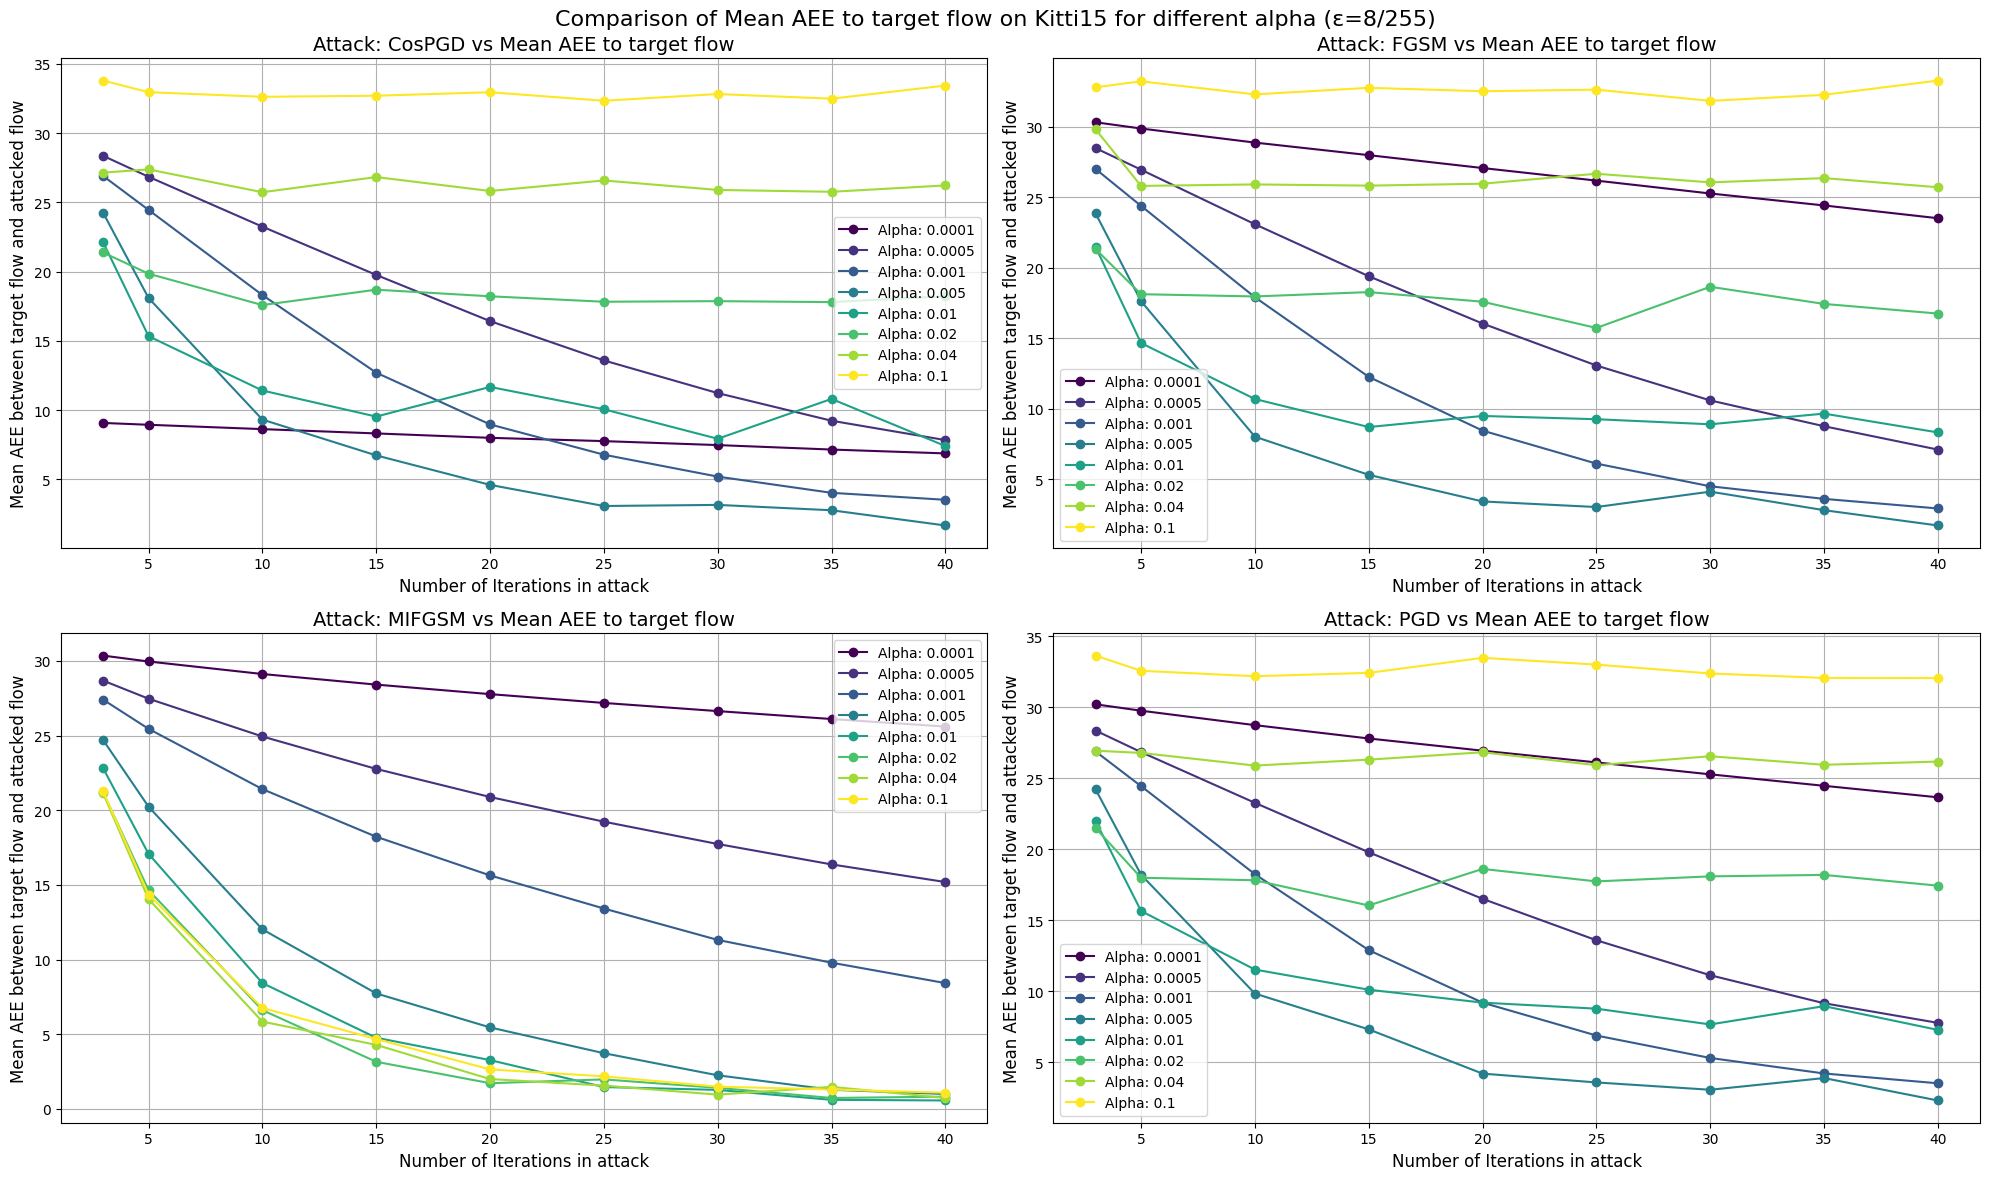

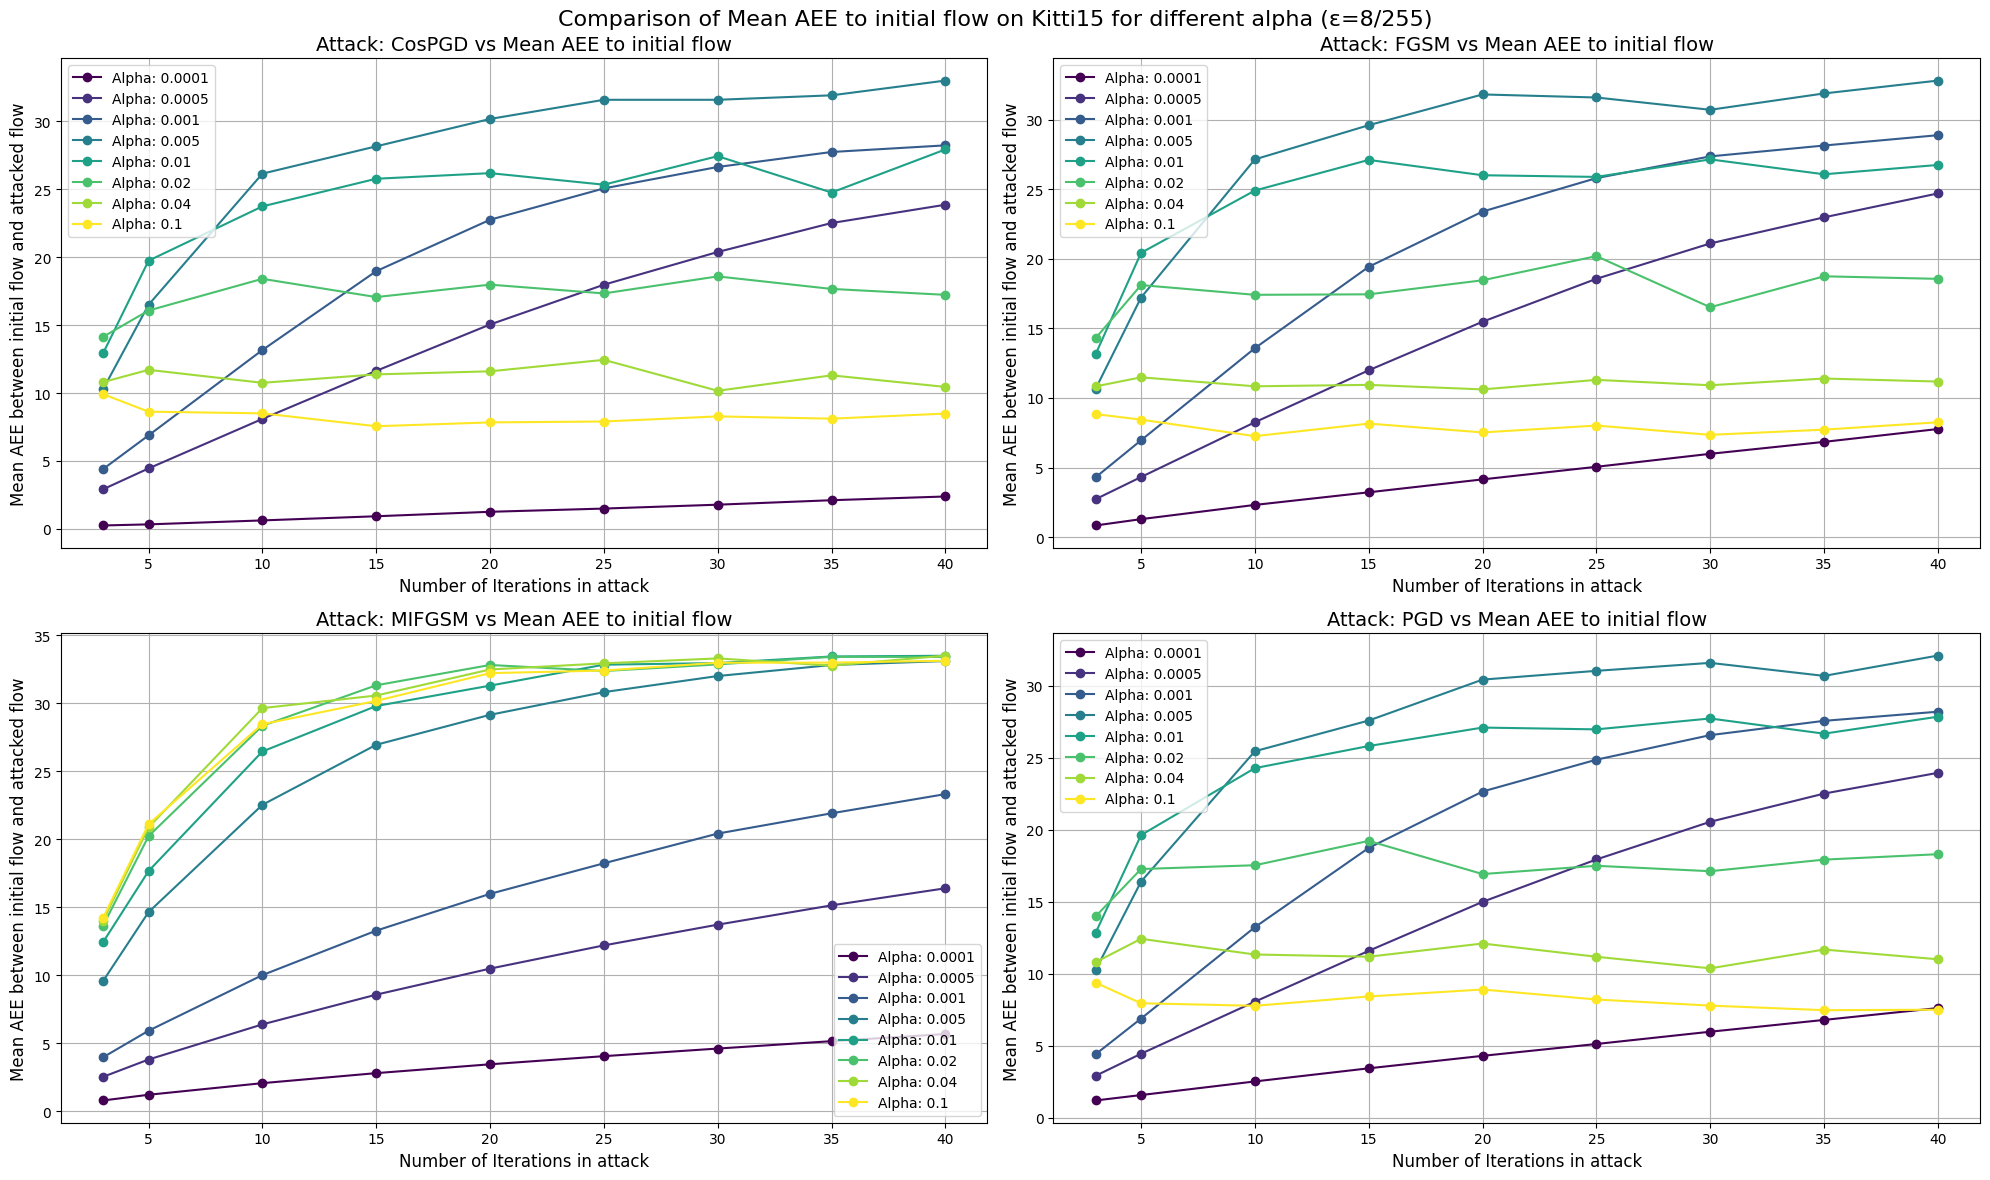

In [32]:
plot_alpha_vs_aee(runs)
plot_alpha_vs_aee(runs, 'mean_aee_init_attack_step_')

In [33]:
# OPTIMAL ALPHA PER ATTACK
optimal_alphas = {
    "CosPGD": 0.005,
"FGSM": 0.005,
"MIFGSM": 0.02,
"PGD": 0.005,
}
optimal_runs = runs[runs.apply(lambda row: row['params.attack_type'] in optimal_alphas and
                             row['params.alpha'] == str(optimal_alphas[row['params.attack_type']]), axis=1)]

In [53]:
optimal_runs['params.epsilon']

21    0.03137254901960784
30    0.03137254901960784
31    0.03137254901960784
32    0.03137254901960784
Name: params.epsilon, dtype: object

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_epsilon_vs_aee(runs_data, metric='mean_aee_target_attack_step_'):
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")

    # Determine the keyword in the metric name for title adjustment
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    elif "gt" in metric:
        metric_label = "ground truth"
    else:
        metric_label = metric.replace("_", " ")  # Default to metric name

    # Copy and preprocess data
    runs_data = runs_data.copy()
    runs_data["params.alpha"] = runs_data["params.alpha"].astype(float)
    runs_data["params.no_softmax"] = runs_data["params.no_softmax"].astype(str)

    # Ensure categorical values for consistent grouping
    runs_data["params.target_layer"] = runs_data["params.target_layer"].astype(
        str)
    runs_data["params.use_map_scaling"] = runs_data["params.use_map_scaling"].astype(
        bool)

    # Group by attack type
    epsilon_groups = runs_data.groupby("params.epsilon")

    # Get unique (target_layer, use_map_scaling) combinations
    unique_target_layers = sorted(runs_data["params.attack_type"].unique())

    # Assign colors based on unique target layers
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_target_layers)))
    color_map = {layer: colors[idx]
                 for idx, layer in enumerate(unique_target_layers)}

    # Define marker styles for map scaling
    # Square for map scaling, Circle otherwise
    marker_styles = {True: "s", False: "o"}

    # Create subplots
    fig, axes = plt.subplots(1, 1, figsize=(20, 12))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()

    fig.suptitle(
        f'Comparison of Mean AEE to {metric_label} on Kitti15 for different epsilon',
        fontsize=16
    )

    eps_map = {0.00392: '1/255', 0.00784: '2/255',
               0.01568: '4/255', 0.03137: '8/255', 0.03137254901960784: '8/255'}

    for idx, (epsilon, group) in enumerate(epsilon_groups):
        if isinstance(axes, np.ndarray):
            ax = axes[idx]
        else:
            ax = axes
        epsilon = float(epsilon)
        eps_frac = eps_map.get(epsilon, str(epsilon))
        ax.set_title(
            f'Epsilon: {eps_frac} vs Mean AEE to {metric_label}', fontsize=14)
        ax.set_xlabel('Number of Iterations in attack', fontsize=12)
        ax.set_ylabel(
            f'Mean AEE between {metric_label} and attacked flow', fontsize=12)

        for _, row in group.iterrows():
            target_layer = row["params.attack_type"]
            use_map_scaling = row["params.use_map_scaling"]

            # Select color based on target layer
            color = color_map[target_layer]

            # Select marker based on use_map_scaling
            marker = marker_styles[use_map_scaling]

            # Extract attack steps and metric values
            values = {}
            for column, value in row.items():
                if column.startswith('metrics.' + metric):
                    step_number = re.search(r'(\d+)$', column)
                    if step_number:
                        step_number = int(step_number.group(1))
                        values[step_number] = value

            # Sort values by step number
            sorted_items = sorted(values.items())
            sorted_steps = [key for key, _ in sorted_items]
            sorted_metrics = [value for _, value in sorted_items]

            legend_label = f"Attack: {row['params.attack_type']}, alpha: {row['params.alpha']}"
            ax.plot(
                sorted_steps, sorted_metrics, linestyle="-", marker=marker,
                label=legend_label, color=color, markersize=8
            )

        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

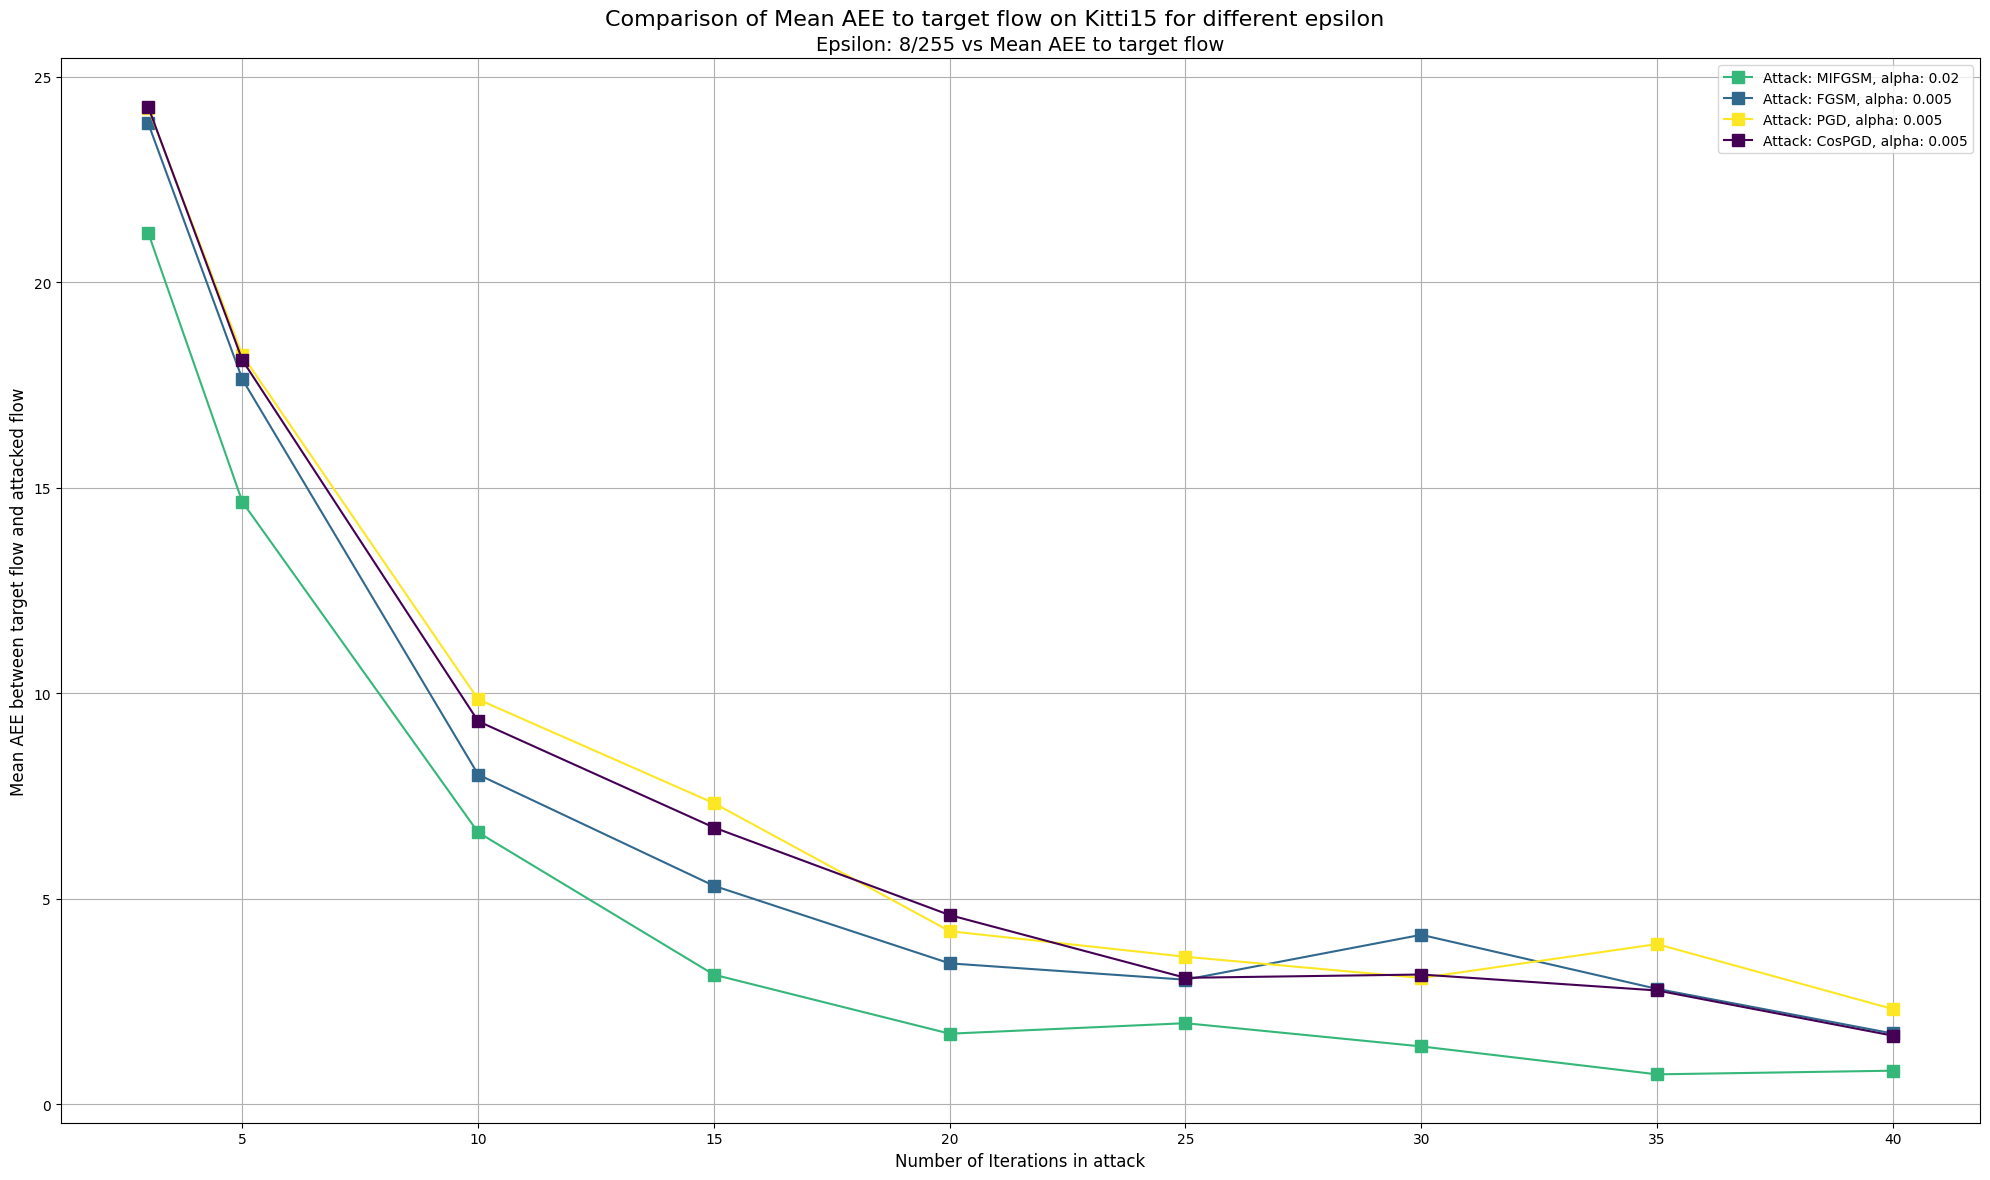

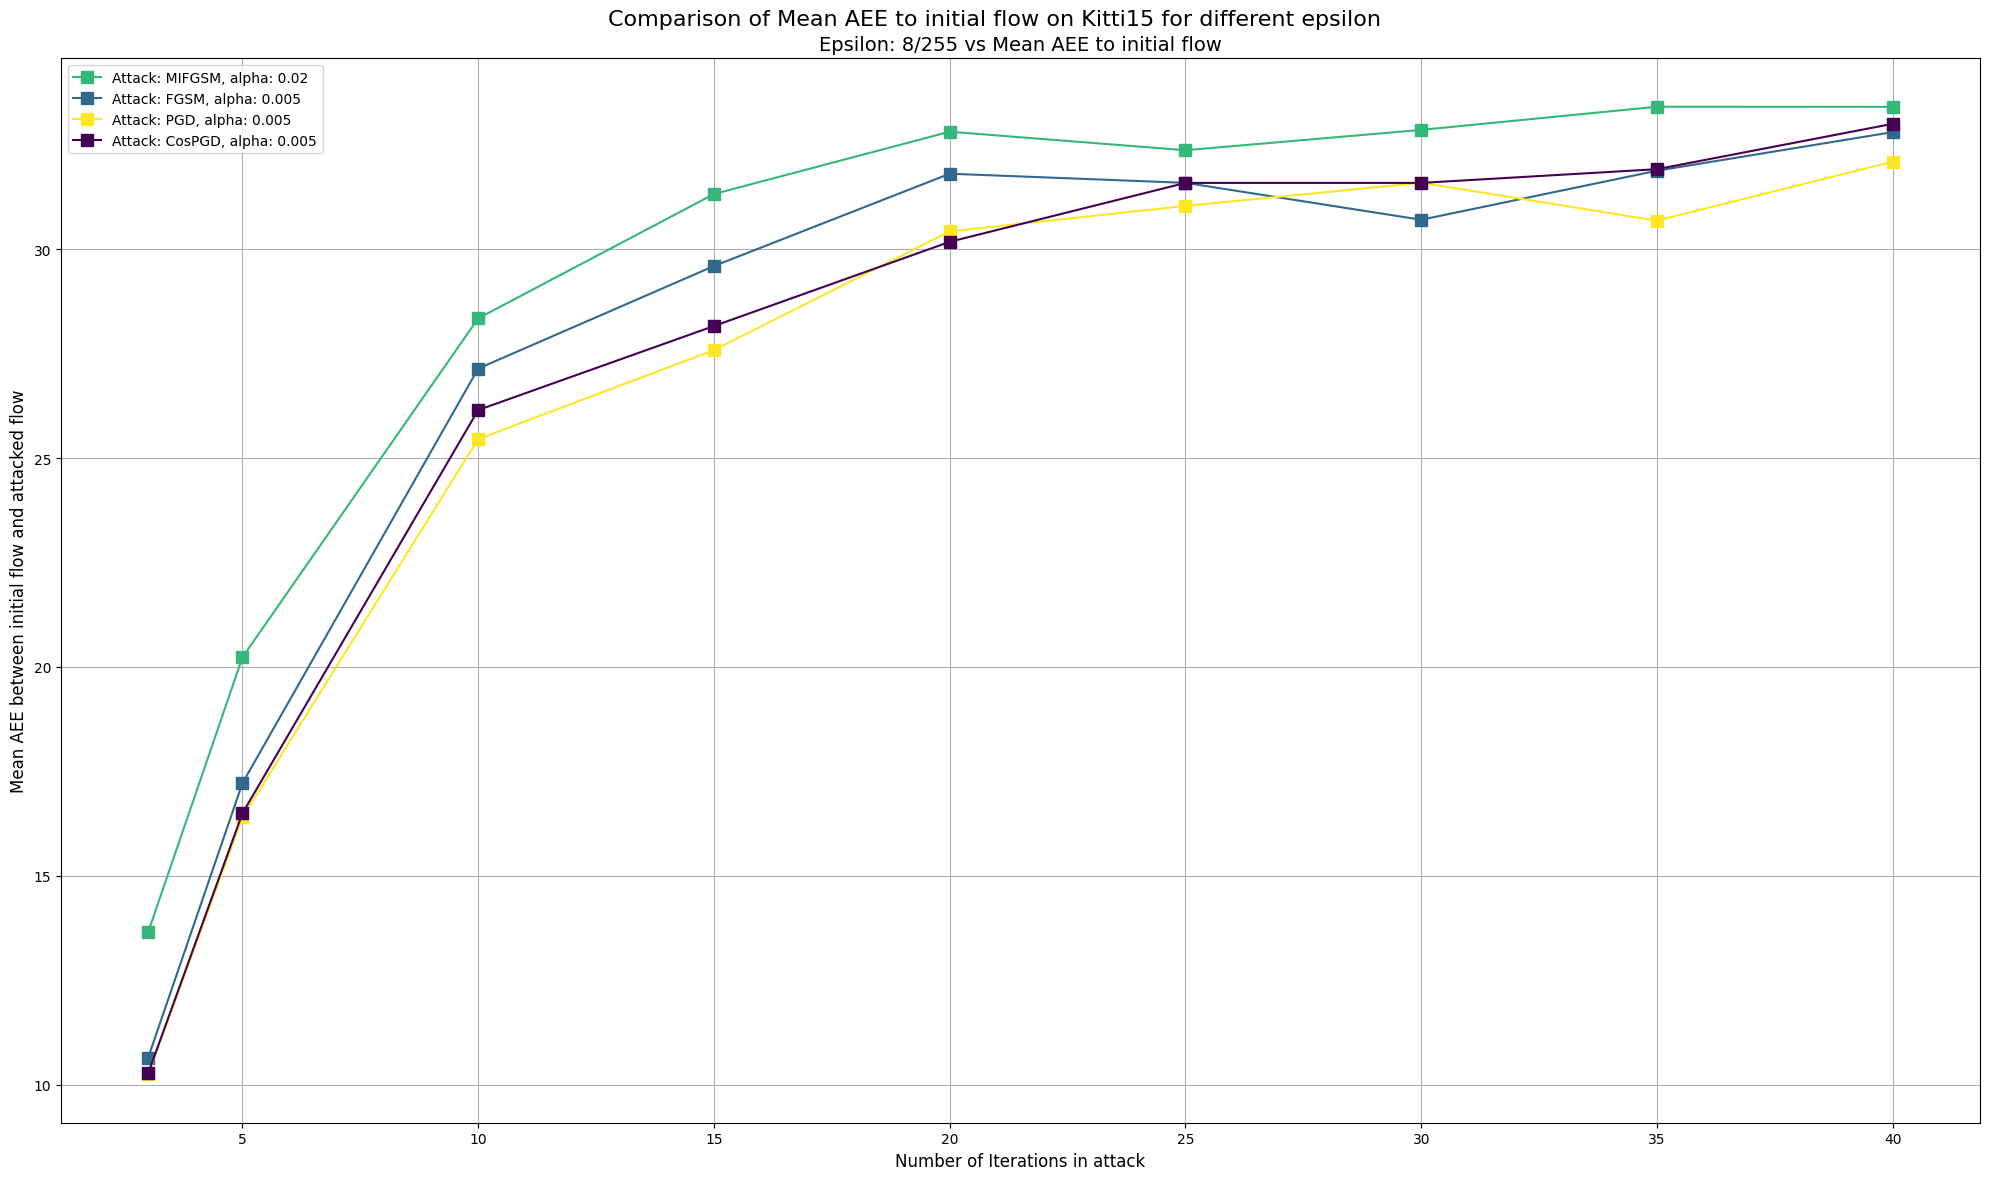

In [58]:
plot_epsilon_vs_aee(optimal_runs)
plot_epsilon_vs_aee(optimal_runs, 'mean_aee_init_attack_step_')

31    703ed7b242ba427893f09a4c86ea10da
Name: run_id, dtype: object